# MLOps Energy Forecasting

## Phase 2.1 - Data Ingestion

This notebook performs the initial data ingestion for the PJM Hourly Energy Consumption dataset.

Objectives:
- Load the dataset
- Verify the dataset path
- Inspect the dataset
- Understand the data structure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
c:\Users\user\mlops-energy-forecasting\notebooks


In [6]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/raw/PJME_hourly.csv")

print("Dataset exists:", DATA_PATH.exists())

df = pd.read_csv(DATA_PATH)

print("✅ Dataset loaded successfully!")
df.head()

Dataset exists: True
✅ Dataset loaded successfully!


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [9]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 145366
Columns : 2


In [10]:
df.columns.tolist()

['Datetime', 'PJME_MW']

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [12]:
df.isnull().sum()

Datetime    0
PJME_MW     0
dtype: int64

In [13]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [14]:
df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [15]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  145366 non-null  datetime64[ns]
 1   PJME_MW   145366 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.2 MB


In [16]:
df = df.set_index("Datetime")

df.head()

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


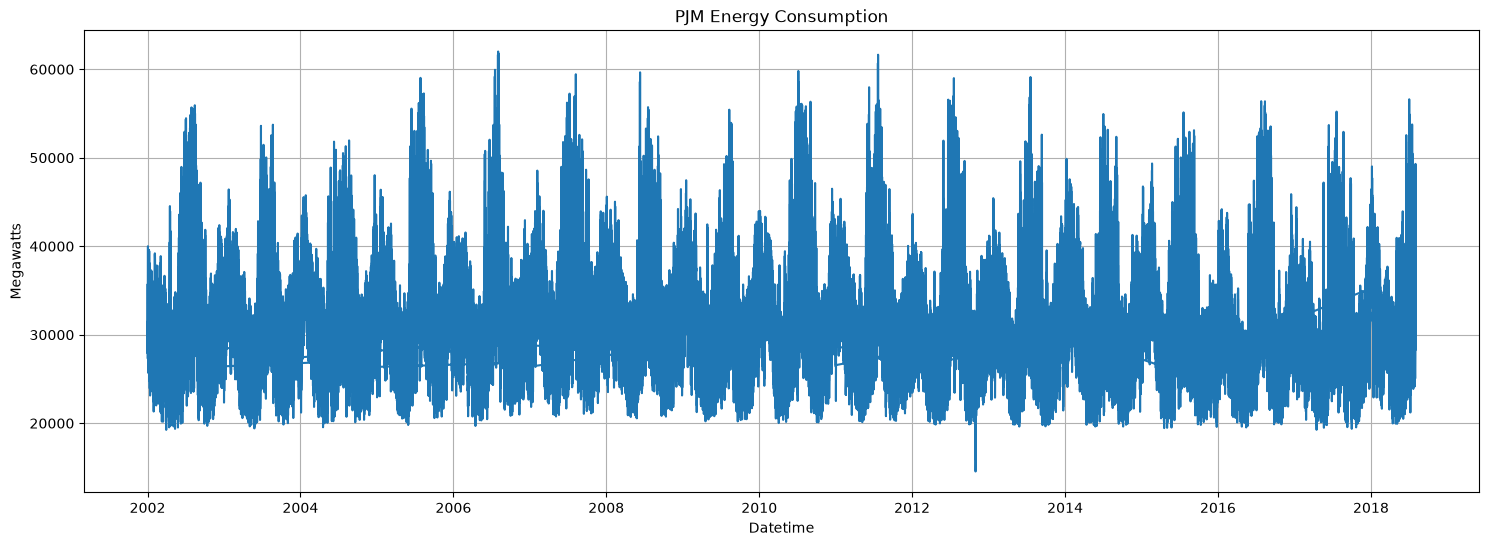

In [17]:
plt.figure(figsize=(18,6))

plt.plot(df.index, df["PJME_MW"])

plt.title("PJM Energy Consumption")

plt.xlabel("Datetime")

plt.ylabel("Megawatts")

plt.grid(True)

plt.show()